In [1]:
! pip install networkx[default] matplotlib ipympl tensorflow[and-cuda]

In [2]:
%matplotlib widget

In [3]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
from tensorflow.keras.optimizers import SGD
import numpy
from matplotlib import pyplot
import networkx
import random
from typing import Iterator
import copy

2025-11-14 20:46:58.626963: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-14 20:46:58.663259: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-14 20:46:59.509548: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [4]:
ROWS = 5
COLS = 5
VERTICES_NUMBER = ROWS * COLS
NUMBER_OF_EDGES_TO_REMOVE = 15
SEED = 144

START_VERTEX = 0
FINISH_VERTEX = 20

In [5]:
class AdjacencyListGraph:
    def __init__(self, vertices_number: int, traffic_signs: dict = None):
        self.vertices: list[set[int]] = [set() for _ in range(vertices_number)]
        self.traffic_signs: dict = (
            copy.deepcopy(traffic_signs) if traffic_signs is not None else dict()
        )

    def get_vertices_number(self) -> int:
        return len(self.vertices)

    def set_relation(self, x: int, y: int):
        self.vertices[x].add(y)

    def remove_relation(self, x: int, y: int):
        self.vertices[x].discard(y)
        self.traffic_signs.pop((x, y), None)
        self.traffic_signs.pop((y, x), None)

    def has_relation(self, x: int, y: int):
        return y in self.vertices[x]

    def is_connected(self):
        visited = [False] * len(self.vertices)

        def dfs(vertex_number: int):
            visited[vertex_number] = True
            for neighbour_number in self.vertices[vertex_number]:
                if not visited[neighbour_number]:
                    dfs(neighbour_number)

        dfs(0)
        return all(visited)

    def copy(self):
        graph = AdjacencyListGraph(len(self.vertices), self.traffic_signs)
        for node_index, neighbours in enumerate(self.vertices):
            for neighbour in neighbours:
                graph.set_relation(node_index, neighbour)
        return graph

    def get_neighbours(self, vertex: int):
        return set([*self.vertices[vertex]])

    def edge_list_iterator(self) -> Iterator[tuple[int, int]]:
        for vertex_index, neighbours in enumerate(self.vertices):
            for neighbour in neighbours:
                yield (vertex_index, neighbour)

    def unique_edge_list_iterator(self) -> Iterator[tuple[int, int]]:
        sended = set()
        for vertex_index, neighbours in enumerate(self.vertices):
            for neighbour in neighbours:
                if (neighbour, vertex_index) in sended:
                    continue
                sended.add((vertex_index, neighbour))
                yield (vertex_index, neighbour)

    def contains_vertex(self, vertex: int) -> bool:
        return vertex < self.get_vertices_number() and self.vertices[vertex] is not None

    def add_traffic_sign(self, vertex1: int, vertex2: int, sign, label):
        self.traffic_signs[(vertex1, vertex2)] = (sign, label)
        self.traffic_signs[(vertex2, vertex1)] = (sign, label)

    def get_traffic_sign(self, vertex1: int, vertex2: int):
        return self.traffic_signs[(vertex1, vertex2)]

In [6]:
def create_grid_graph(rows: int, cols: int) -> AdjacencyListGraph:
    graph = AdjacencyListGraph(VERTICES_NUMBER)
    for i in range(rows):
        for j in range(cols):
            if j + 1 < cols:
                graph.set_relation(i * cols + j, i * cols + j + 1)
                graph.set_relation(i * cols + j + 1, i * cols + j)
            if i + 1 < rows:
                graph.set_relation(i * cols + j, (i + 1) * cols + j)
                graph.set_relation((i + 1) * cols + j, i * cols + j)
    return graph

In [7]:
def delete_graph_edges(
    graph: AdjacencyListGraph, edges_number: int
) -> AdjacencyListGraph:
    processed_graph = graph.copy()
    relations = tuple(processed_graph.edge_list_iterator())
    i = 0
    while i < edges_number:
        vertex1, vertex2 = random.choice(relations)
        if not processed_graph.has_relation(vertex1, vertex2):
            continue
        traffic_sign = graph.get_traffic_sign(vertex1, vertex2)
        processed_graph.remove_relation(vertex1, vertex2)
        processed_graph.remove_relation(vertex2, vertex1)
        if not processed_graph.is_connected():
            processed_graph.set_relation(vertex1, vertex2)
            processed_graph.set_relation(vertex2, vertex1)
            processed_graph.add_traffic_sign(vertex1, vertex2, *traffic_sign)
            continue
        i += 1
    return processed_graph

In [8]:
def get_searching_path(graph: AdjacencyListGraph, start: int, finish: int) -> list[int]:
    if not graph.contains_vertex(start) or not graph.contains_vertex(finish):
        return []
    if not graph.is_connected() or start == finish:
        return []

    visited = [False] * graph.get_vertices_number()

    def dfs(vertex: int, neighbours: set[int], path: list[int]):
        visited[vertex] = True
        path.append(vertex)
        if finish in neighbours:
            path.append(finish)
            return path
        for neighbour in neighbours:
            neighbors_neighbors = graph.get_neighbours(neighbour)
            if not visited[neighbour] and len(neighbors_neighbors.difference(path)) > 0:
                dfs(neighbour, neighbors_neighbors, path)
                if path[-1] == finish:
                    break
                path.append(vertex)
        return path

    return dfs(start, graph.get_neighbours(start), [])

In [9]:
def visualize_path(
    graph: AdjacencyListGraph, path: list[int], detected_signs: list[int]
):
    position = {
        i: (i % COLS, ROWS - 1 - (i // ROWS))
        for i in range(graph.get_vertices_number())
    }
    display_graph = networkx.Graph()
    display_graph.add_nodes_from(range(graph.get_vertices_number()))
    for vertex1, vertex2 in graph.unique_edge_list_iterator():
        _, label = graph.get_traffic_sign(vertex1, vertex2)
        display_graph.add_weighted_edges_from([(vertex1, vertex2, label * 10)])

    edge_labels = networkx.get_edge_attributes(display_graph, "weight")
    _, ax = pyplot.subplots(figsize=(6, 6))

    edge_colors = []
    for vertex1, vertex2 in display_graph.edges():
        edge_colors.append("lightgray")

    edges_list = list(display_graph.edges())
    prev_vertex = -1
    for i, current_vertex in enumerate(path):
        ax.clear()
        node_colors = ["lightgray"] * graph.get_vertices_number()
        if prev_vertex != -1:
            real_weight = display_graph[prev_vertex][current_vertex]["weight"]
            predicted_weight = detected_signs[i - 1] * 10
            try:
                edge_index = edges_list.index((prev_vertex, current_vertex))
            except ValueError:
                edge_index = edges_list.index((current_vertex, prev_vertex))

            if real_weight != predicted_weight:
                edge_colors[edge_index] = "red"
            else:
                edge_colors[edge_index] = "green"

        for visited in path[: i + 1]:
            node_colors[visited] = "orange"

        node_colors[current_vertex] = "red" if i != len(path) - 1 else "green"

        networkx.draw(
            display_graph,
            pos=position,
            with_labels=True,
            node_color=node_colors,
            edge_color=edge_colors,
            ax=ax,
        )
        networkx.draw_networkx_edge_labels(
            display_graph, pos=position, edge_labels=edge_labels, ax=ax, rotate=False
        )
        ax.set_title(f"Step {i + 1} - visiting vertex {current_vertex}")
        pyplot.pause(0.5)
        prev_vertex = current_vertex

    pyplot.show()

In [10]:
def prep_pixels(train, test):
    train_norm = train.astype("float32")
    test_norm = test.astype("float32")
    train_norm = train_norm / 255.0
    test_norm = test_norm / 255.0
    return train_norm, test_norm

In [11]:
def load_dataset():
    (trainX, trainY), (testX, testY) = mnist.load_data()

    trainX = trainX.reshape((trainX.shape[0], 28, 28, 1))
    testX = testX.reshape((testX.shape[0], 28, 28, 1))

    trainX, testX = prep_pixels(trainX, testX)

    trainY = to_categorical(trainY)
    testY = to_categorical(testY)

    return trainX, trainY, testX, testY

In [12]:
def define_model():
    model = Sequential()
    model.add(
        Conv2D(
            32,
            (3, 3),
            activation="relu",
            kernel_initializer="he_uniform",
            input_shape=(28, 28, 1),
        )
    )
    model.add(MaxPooling2D((2, 2)))
    model.add(Flatten())
    model.add(Dense(100, activation="relu", kernel_initializer="he_uniform"))
    model.add(Dense(10, activation="softmax"))
    opt = SGD(learning_rate=0.01, momentum=0.9)
    model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])
    return model

In [13]:
def select_traffic_signs(images, labels, size):
    result = []
    index = 0
    while len(result) < size:
        number = numpy.argmax(labels[index])
        if number >= 2:
            result.append((images[index], number))
        index += 1
    return result

In [14]:
def add_traffic_signs(graph: AdjacencyListGraph, traffic_signs):
    for index, (x, y) in enumerate(graph.unique_edge_list_iterator()):
        graph.add_traffic_sign(x, y, *traffic_signs[index])

In [15]:
def detect_traffic_signs(
    graph: AdjacencyListGraph, path: list[int], model
) -> list[int]:
    if len(path) <= 1:
        return []

    transformed_path: list[tuple[int, int]] = []
    for index in range(1, len(path)):
        transformed_path.append((path[index - 1], path[index]))

    result = []
    for vertex1, vertex2 in transformed_path:
        traffic_sign, _ = graph.get_traffic_sign(vertex1, vertex2)
        predict = model.predict(numpy.expand_dims(traffic_sign, axis=0))[0]
        predicted_sign = numpy.argmax(predict).item()
        result.append(predicted_sign)
    return result

/home/serhii/labs/introduction-to-ai/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-11-14 20:47:00.414010: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9511 - loss: 0.1649
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


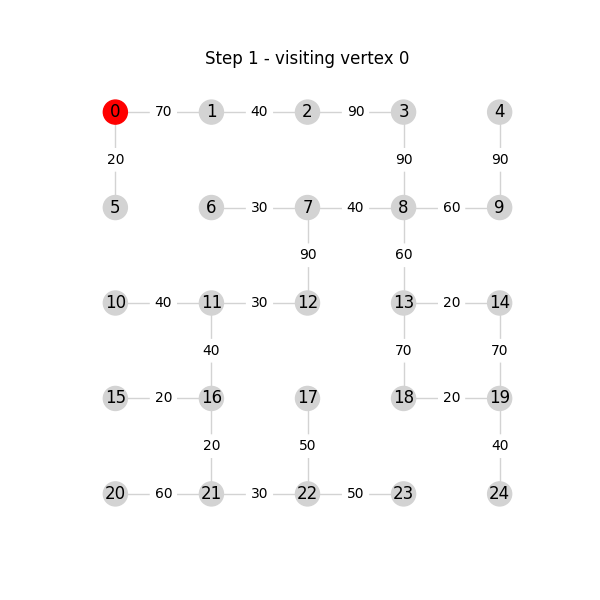

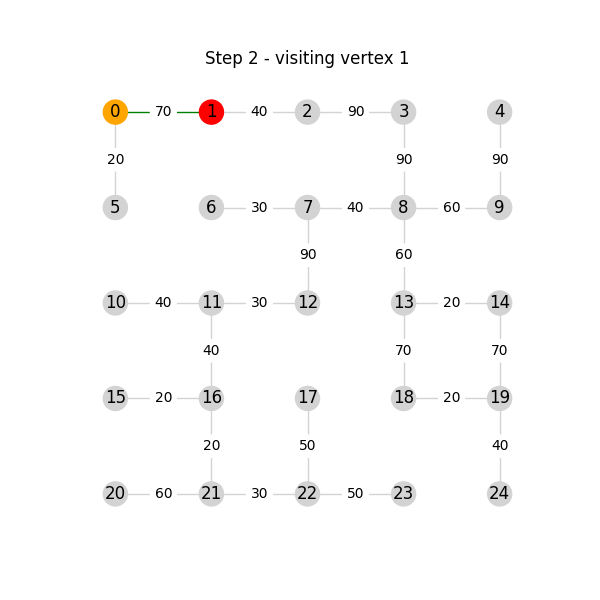

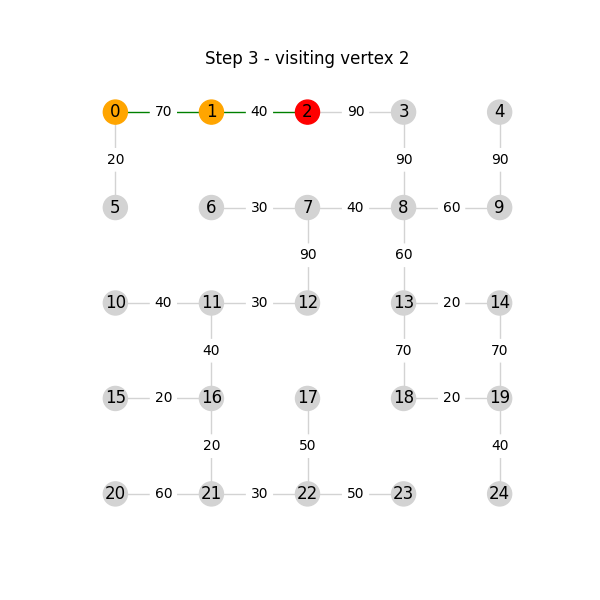

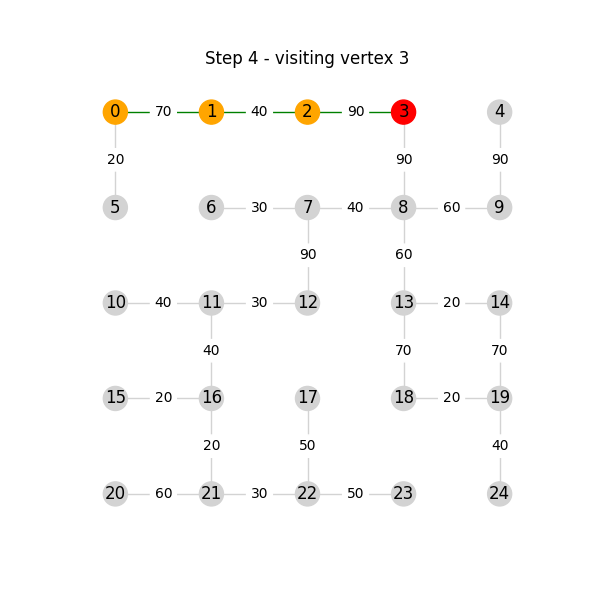

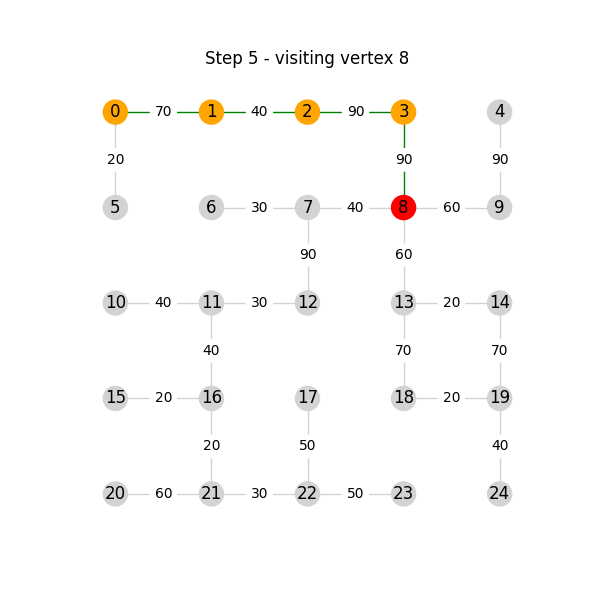

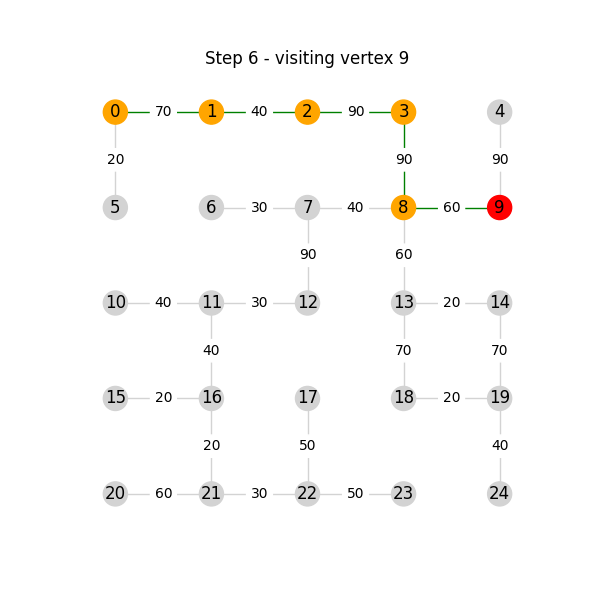

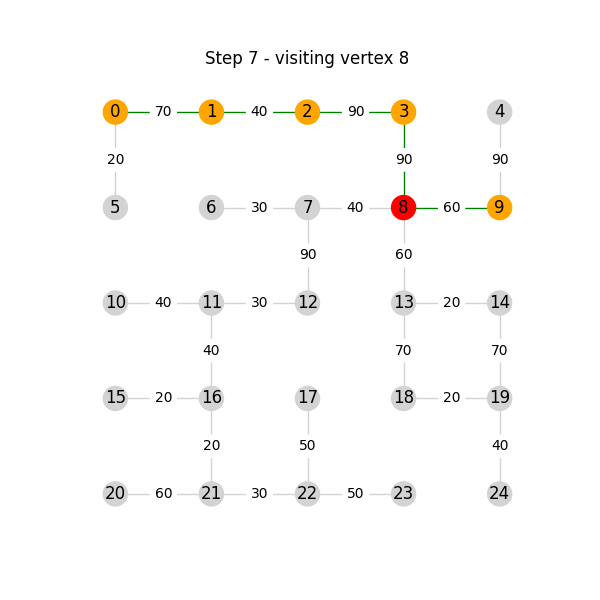

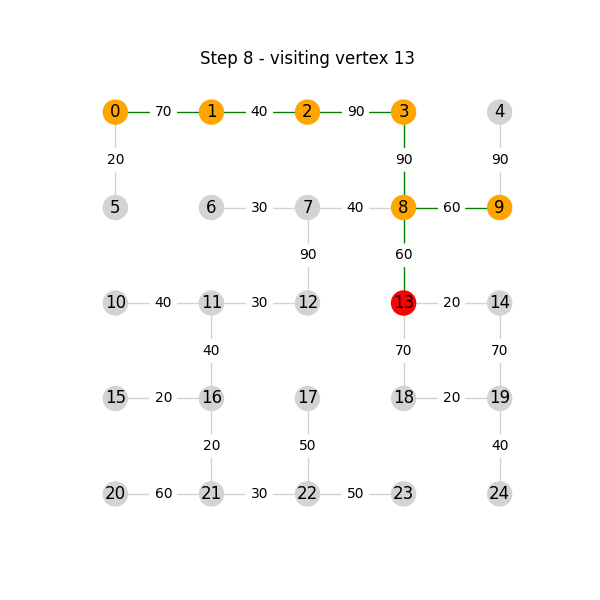

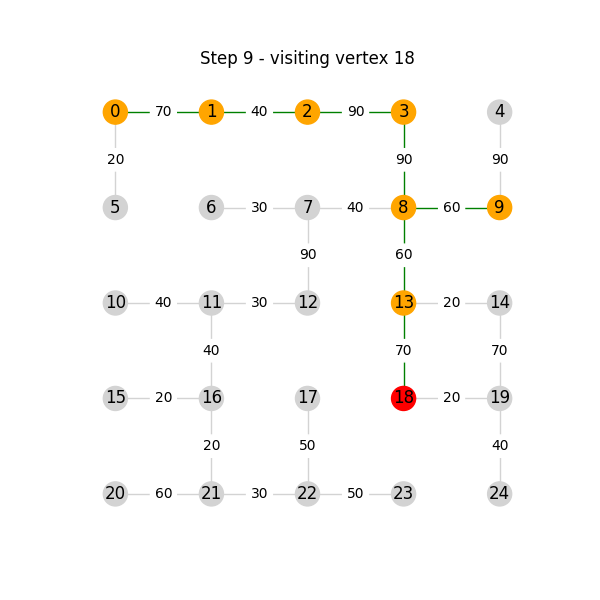

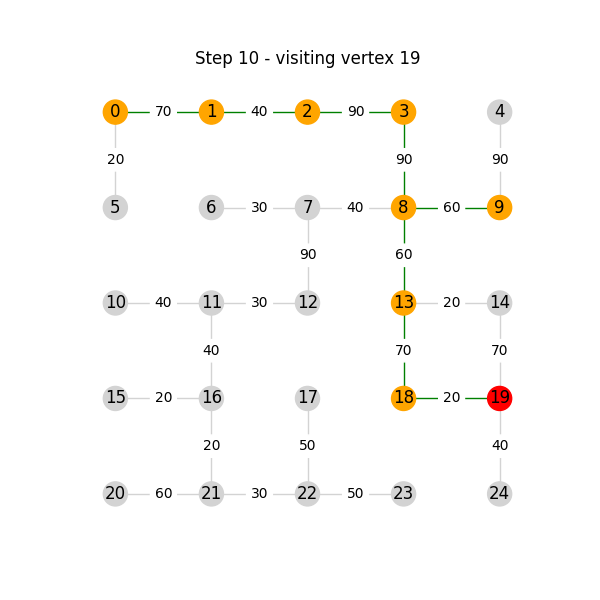

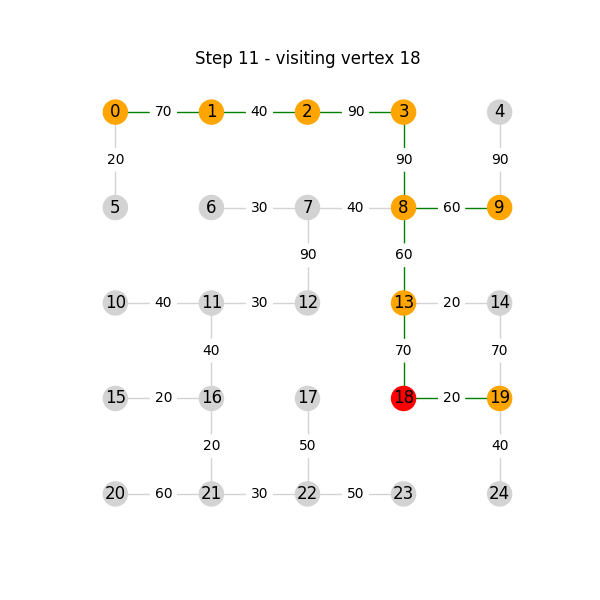

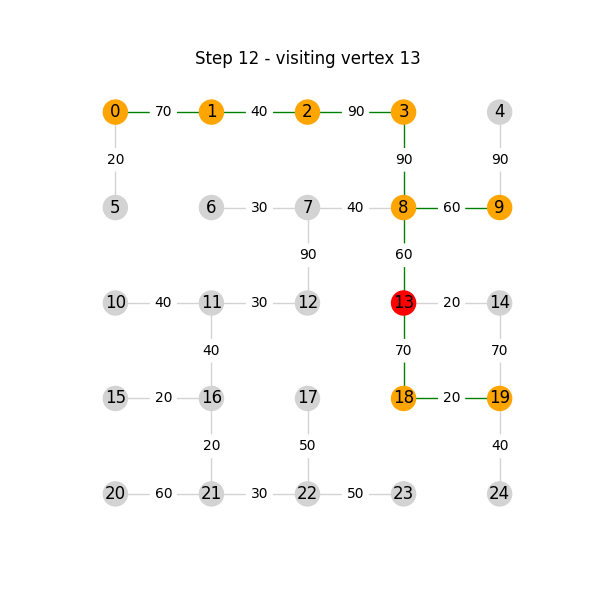

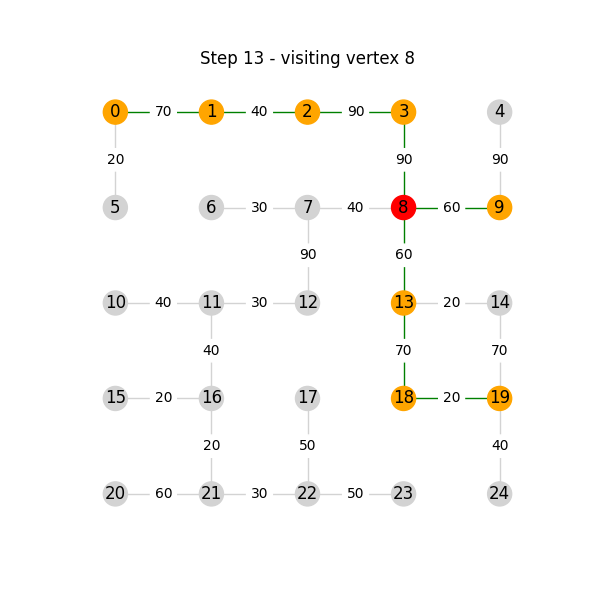

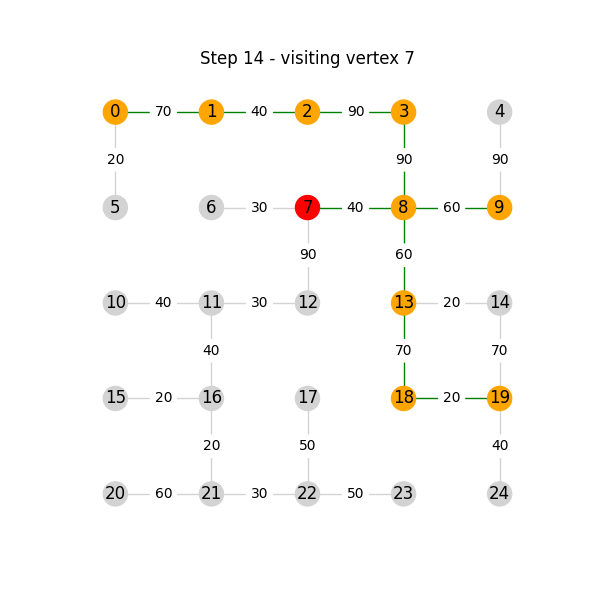

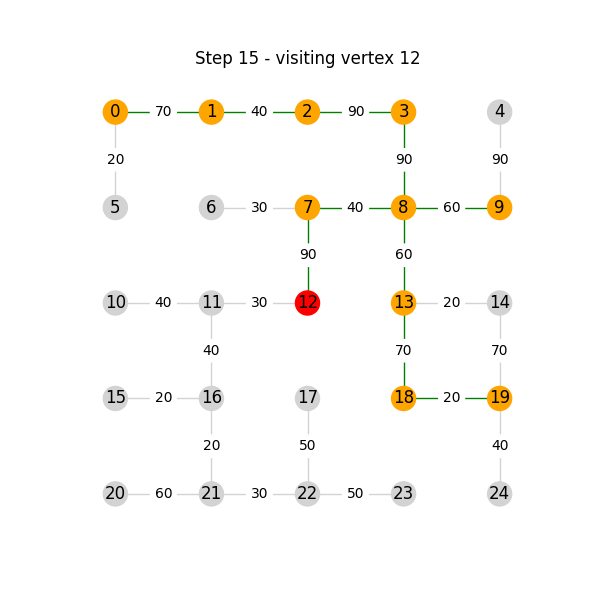

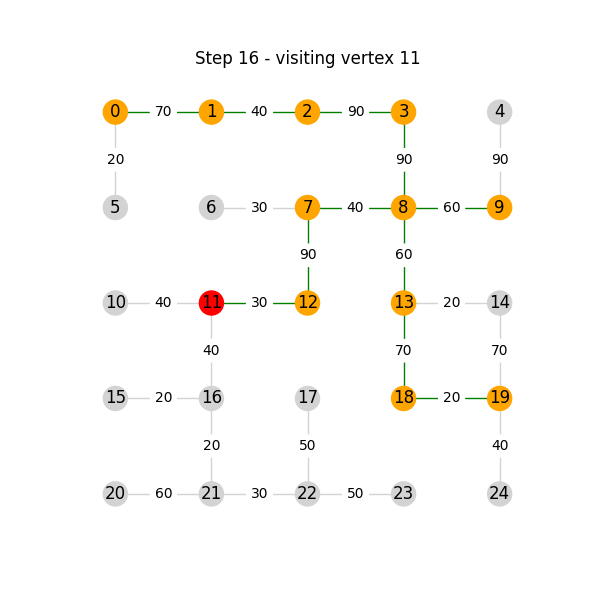

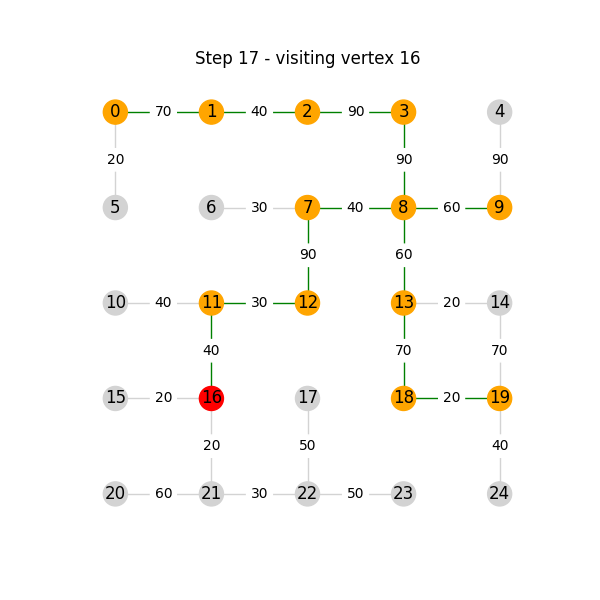

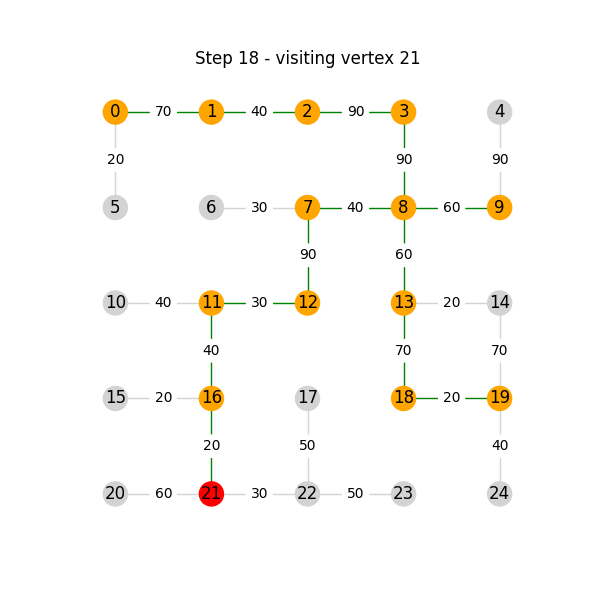

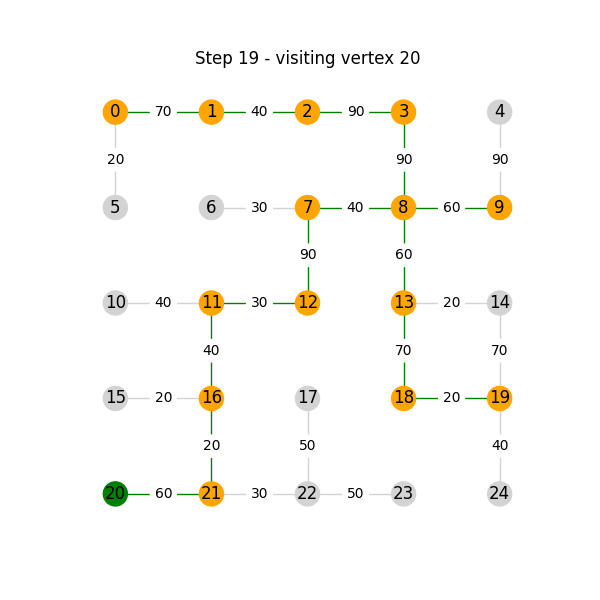

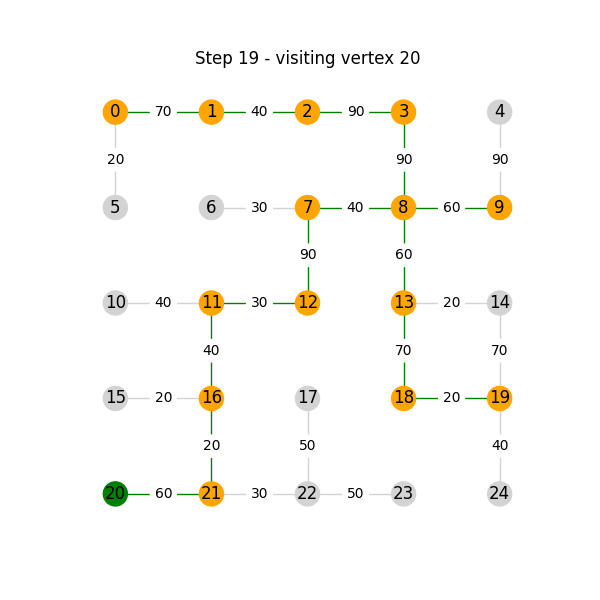

In [16]:
def main():
    total_edges_number = (ROWS - 1) * COLS + (COLS - 1) * ROWS

    trainX, trainY, testX, testY = load_dataset()
    traffic_signs = select_traffic_signs(testX, testY, total_edges_number)

    model = define_model()
    model.fit(trainX, trainY, epochs=1, batch_size=32)

    random.seed(SEED)
    graph = create_grid_graph(ROWS, COLS)
    add_traffic_signs(graph, traffic_signs)

    processed_graph = delete_graph_edges(graph, NUMBER_OF_EDGES_TO_REMOVE)
    searching_path = get_searching_path(processed_graph, START_VERTEX, FINISH_VERTEX)
    detected_signs = detect_traffic_signs(processed_graph, searching_path, model)
    visualize_path(processed_graph, searching_path, detected_signs)


if __name__ == "__main__":
    main()